In [1]:
import gwsurrogate

/home/omkarnm1401/miniconda3/envs/ut_codex/lib/python3.11/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
import pandas as pd

In [3]:
from gwtools.gwtools import minimize_norm_error_multi_mode

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
# add the path to the script directory
sys.path.append("/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates")
import BHPTNRSur1dq1e4 as bhptsur

/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates/../data
**** Surrogate loaded: BHPTNRSur1dq1e4 ****


In [5]:
import matplotlib as mpl

sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
import bhpt_utils
mpl.rcdefaults()

In [6]:
nrsur = gwsurrogate.LoadSurrogate('NRHybSur3dq8')

Loaded NRHybSur3dq8 model


In [7]:
# convience wrapper for calling the NRHybSur3dq8 model
def generate_nrsur(q_input, f_low=None, t_start=None):
    chiA = [0, 0, 0.0]
    chiB = [0, 0, 0.0]
    dt = 0.1        # step size, Units of M
    if f_low==None:
        f_low=5e-3
    if t_start==None:
        t_start=-5000.1
    # dyn stands for dynamics and is always None for this model
    t, h, dyn = nrsur(q_input, chiA, chiB, dt=dt, f_low=f_low) 
    # we only take the last 5000M long waveform to calibrate
    indx = np.where(t>=t_start)
    t = t[indx]
    for mode in h.keys():
        h[mode] = h[mode][indx]
    return t,h

In [8]:
tnr, h_NRHybSur3dq8 = generate_nrsur(q_input=5)

In [9]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhpt, hbhpt = bhptsur.generate_surrogate(q=5, modes=h_NRHybSur3dq8.keys(), calibrated=False, neg_modes=False)

**** warning **** : modes are NOT NR calibrated - waveforms only have 0PA contribution


In [10]:
q_input = 5
mass_norm = 1/(1+1/q_input)

In [11]:
h_NR_22 = h_NRHybSur3dq8[(2, 2)]

In [12]:
import gwtools

In [13]:
def mathcalE_error(h1, h2):
    """
    Compute time-domain waveform error.

    Calculates the normalized L2 error between two waveforms using the metric
    defined in Eq. 21 of https://arxiv.org/pdf/1701.00550.pdf

    Parameters:
    -----------
    h1 : array (complex)
        Reference waveform (used for normalization)
    h2 : array (complex)
        Comparison waveform (same length as h1)

    Returns:
    --------
    normed_errs : float
        Normalized error: (||h1||² + ||h2||² - 2*Re(<h1,h2>)) / (2*||h1||²)
        Value of 0 indicates perfect agreement, larger values indicate greater disagreement

    Notes:
    ------
    - Assumes h1 is the reference waveform and normalizes by its magnitude
    - Both waveforms should have the same time sampling
    - The metric is symmetric in the numerator but asymmetric due to normalization by ||h1||²
    """
    # Compute norms squared
    n1Sqr = np.sum(np.abs(h1)**2)
    n2Sqr = np.sum(np.abs(h2)**2)

    # Compute inner product
    dots = np.array([h1[i] * (h2[i].conjugate()) for i in range(len(h1))])
    sdot = np.real(np.sum(dots))

    # Normalize error by reference waveform magnitude
    normed_errs = ((n1Sqr + n2Sqr) - 2 * sdot) / (2 * n1Sqr)

    return normed_errs

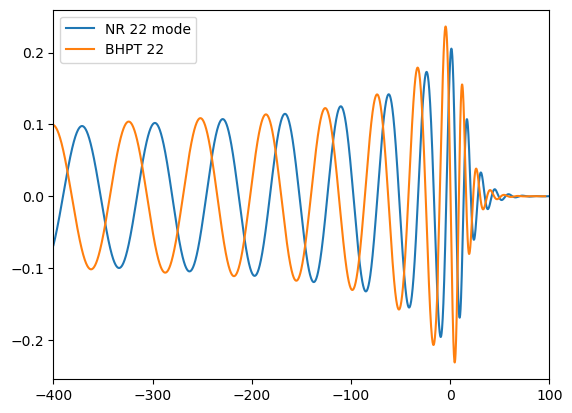

In [14]:
plt.plot(tnr, np.real(h_NR_22), label = 'NR 22 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(2,2)])  * mass_norm, label = 'BHPT 22')

plt.xlim(-400, 100)
plt.legend()

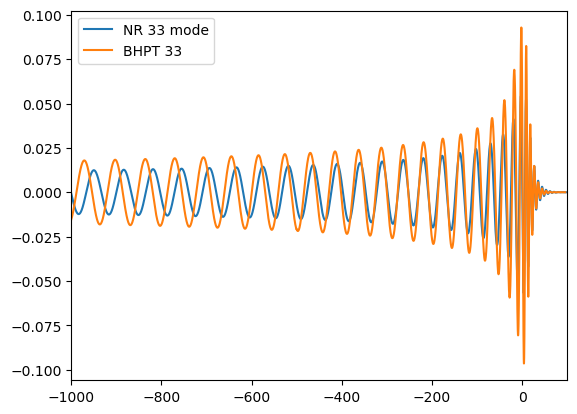

In [15]:
h_nr_33 = h_NRHybSur3dq8[(3, 3)]

plt.plot(tnr, np.real(h_nr_33), label = 'NR 33 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(3,3)])  * mass_norm, label = 'BHPT 33')

plt.xlim(-1000, 100)
plt.legend()

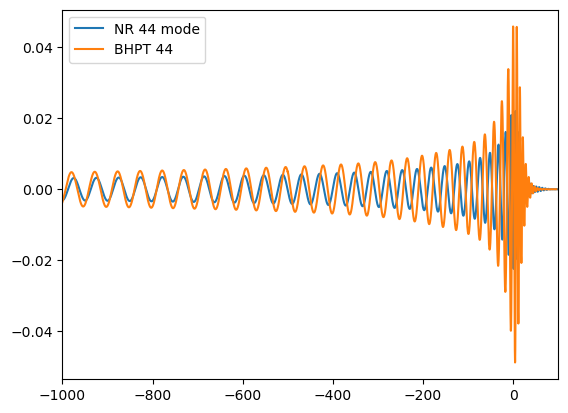

In [16]:
h_nr_44 = h_NRHybSur3dq8[(4, 4)]

plt.plot(tnr, np.real(h_nr_44), label = 'NR 44 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(4, 4)])  * mass_norm, label = 'BHPT 44')

plt.xlim(-1000, 100)
plt.legend()

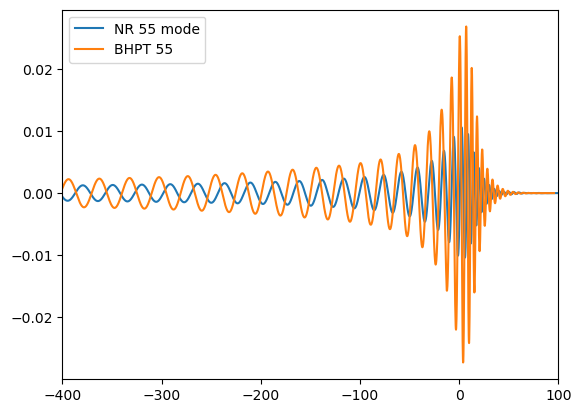

In [17]:
h_nr_55 = h_NRHybSur3dq8[(5, 5)]

plt.plot(tnr, np.real(h_nr_55), label = 'NR 55 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(5, 5)])  * mass_norm, label = 'BHPT 55')

plt.xlim(-400, 100)
plt.legend()

In [18]:
h_bhpt_interp = gwtools.interpolate_h(tbhpt * mass_norm, hbhpt[(2,2)], tnr)
mathcalE_error(h_NR_22, h_bhpt_interp)

>>> Warning: Requested samples are outside of interpolated domain.


np.float64(1.358614394200636)

In [19]:
# %load scaling.md
#Using the low-order time-dependent fit for `q=5`, `(2,2)`, I get:


t_min = -6188.39999991155
t_max = 114.800000111376
def x(t):
    return 2 * (t - t_min) / (t_max - t_min) - 1

#Amplitude scaling:


def alpha(t):
    return  0.806734255287305 + (-0.00893045394034559) * x(t)


#Time map:

#```python
def tau(t):
    tau0 = -4970.7102530274
    u = t - t_min
    beta0 = 0.803628877212988
    beta1 = -0.000811064523098718
    return tau0 + beta0 * u + beta1 * (u**2 / (t_max - t_min) - u)
#```

#So the corresponding time-dependent beta is:

#```python
def beta(t):
    beta0 = 0.803628877212988
    beta1 = -0.000811064523098718
    return beta0 + beta1 * x(t)
#```

#I also included a constant phase rotation:

#```python
#phi0 = 1.97530886542818  # radians
#```

#Applied as:

#```python
tbhpt_extcal = tau(tbhpt)

hbhpt_extcal = {
    (2, 2): alpha(tbhpt) * hbhpt[(2,2)]
}
#```

#With common-support interpolation, this gave:

# ```text
# mathcalE = 0.0223913001494002
# ```

# on NR support approximately `[-4998.76, 86.97]`, so it is comfortably below the updated `< 1` target.


In [20]:
[errors_before_min, errors_after_min], [tc, phic], [common_times,h_bhpt_aligned,h_nr_aligned] = \
                            minimize_norm_error_multi_mode(tau(tbhpt),  hbhpt_extcal, tnr, h_NRHybSur3dq8, mode_list=None, ell_m_match=(2,2),\
                                    t_low_adj=0,t_up_adj=0,method='nelder-mead')

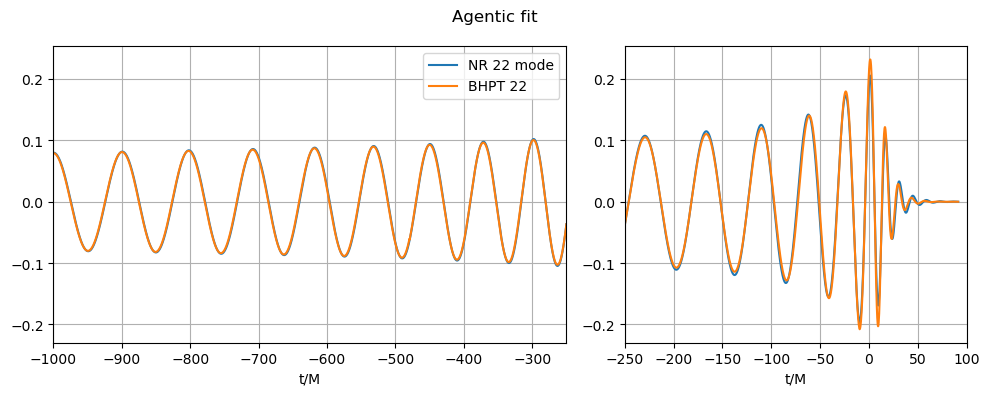

In [21]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax1.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax2.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

plt.suptitle('Agentic fit')


plt.tight_layout()
plt.show()

In [22]:
errors_before_min, errors_after_min

({(2, 2): np.float64(0.0018799131991482176)},
 np.float64(0.0018799131991482176))

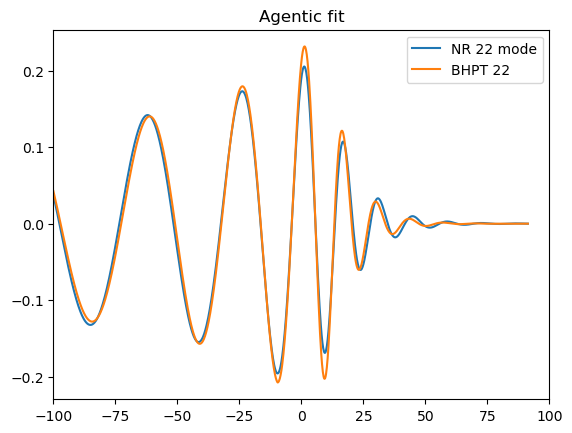

In [23]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]

plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
plt.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

plt.xlim(-100, 100)
plt.title('Agentic fit')

plt.legend()
plt.show()

In [24]:
modes = [(2,2)]
ab = bhpt_utils.all_alpha_beta_1D_scaling_params(q_input, modes)
print(ab)

{'beta': 0.803656511773389, 'alpha_l2m2': 0.804414592200569}


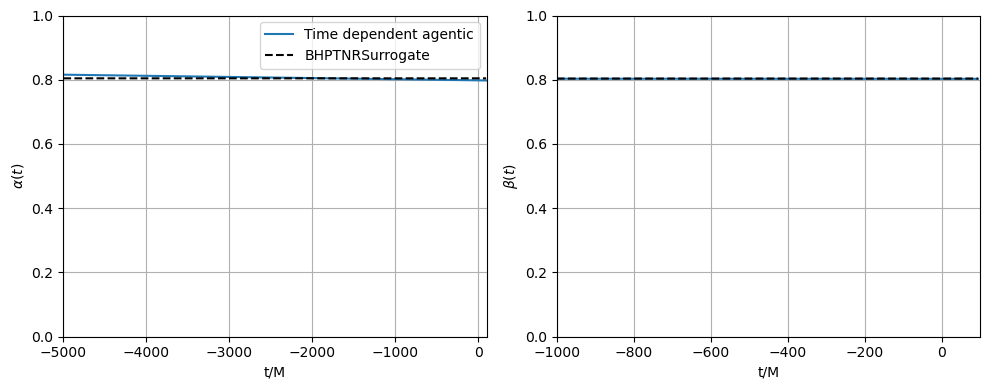

In [26]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [2, 2]}
)



#ax1.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax1.plot(tbhpt_extcal, alpha(tbhpt), label = 'Time dependent agentic')
ax1.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['alpha_l2m2'], label = 'BHPTNRSurrogate', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-5000, 100)
ax1.set_ylim(0, 1)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.set_ylabel(r'$\alpha(t)$')
ax1.legend()

#ax2.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax2.plot(tbhpt_extcal, beta(tbhpt))
ax2.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['beta'], linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')
ax2.set_ylabel(r'$\beta(t)$')
ax2.set_ylim(0, 1)

ax2.set_xlim(-1000, 100)
ax2.grid(True)

#plt.suptitle('Agentic fit')


plt.tight_layout()
#plt.savefig(plot_dir + f'q_and_t_dependent_agentic_fit_params_q={q_input}.pdf')
plt.show()